<a href="https://colab.research.google.com/github/JJolon-dev/OMBIM/blob/main/Actividad_1_An%C3%A1lisis_Exploratorio_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 1 - Análisis Exploratorio y Mejoras a Conjunto de Datos

Este ejercicio considera realizar un análisis exploratorio de un dataset y hacer algunas mejoras iniciales, con el objetivo de mejorar la calidad de datos para un buen desempeño de modelos de predicción categórica.

El foco está en reconocer defectos en un dataset y hacer algunos ajustes y mejoras.

## Contexto: Bandas de Cilindro en la Impresión Rotograbado

Fuente: https://archive.ics.uci.edu/dataset/32/cylinder+bands

La motivación viene de los retrasos en el proceso conocidos como bandas de cilindro en la impresión rotograbado. La mitigación de estos retrasos se logró originalmente por el uso reglas de control descubiertas mediante la inducción de árboles de decisión. Este proyecto ejemplifica una metodología más general que transforma la tarea de adquisición de conocimientos de una en la que las reglas se elicitaban directamente de un experto, a una en la que un sistema de aprendizaje (modelo machine learning) es responsable de la generación de reglas.

Posteriormente, en un proceso de aprendizaje supervisado, se busca predecir automáticamente el atributo "Change" en base a todo el resto. Para esta actividad, dicho atributo representa si el cilindro se cambió (YES) o no (NO).  

Este conjunto de datos (abierto para este tipo de usos instruccionales), consiste en 40 atributos, incluyendo varios datos categóricos, que según el análisis, cada uno de ellos puede ser una etiqueta.

Esta adaptación en particular, por el equipo de GUX (GUX.tech), liderado por Rodrigo Sandoval, enfrenta diferentes objetivos de aprendizaje dentro de los cursos de Big Data y Machine Learning.

En particular, esta versión del ejercicio sólo se plantea como una actividad de aprendizaje, sin estar sujeta a evaluación.

## Paso 1: Instación de las librerías

Esto se ejecuta sólo una vez al comienzo de la sesión de cada persona. No se necesita volver a ejecutar con cada nueva prueba del resto de los scripts. Aquí se incluyen liberías para ejecutar todos los modelos.

In [ ]:
# Esto toma entre 6 y 8 minutos
install.packages('e1071')
install.packages('caret')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




##Paso 2: Carga y preprocesamiento de los datos ##

Las siguientes instrucciones cargan los datos desde la URL de origen y luego muestra un encabezado con las primeras filas del dataset, para demostrar la disponibilidad de los datos.

Este código se puede ejecutar sólo una vez, si así se prefiere, para uso del dataset resultante en los siguientes pasos.

In [ ]:
# Se declara la URL de dónde obtener los datos
theUrlMain <- "https://rsolver.com/download/CylinderBand.csv"

# Se declaran los nombres de las columnas
columnas = c("timestamp", "Change", "cylinder number", "customer", "job number", "grain screened", "ink color", "proof on ctd ink", "blade mfg", "cylinder division", "paper type", "ink type", "direct steam", "solvent type", "press type", "press", "unit number", "cylinder size", "paper mill location", "plating tank", "proof cut", "viscosity", "caliper", "ink temperature", "humifity", "roughness", "blade pressure", "varnish pct", "press speed", "ink pct", "solvent pct", "ESA Voltage", "ESA Amperage", "wax", "hardener", "roller durometer", "current density", "anode space ratio", "chrome content", "band type")

# Se cargan datos principales a una estructura o dataset (original.dataset), asignando nombres de atributos a las columnas.
# Nótese que se incluye la conversión de valores "?" a "NA" para facilitar la gestión vacíos más adelante.
original.dataset <- read.table(file = theUrlMain, header = TRUE, sep = ";", col.names = columnas, na.strings=c("?","NA"))

# Se muestran las primeras líneas del dataset y sus dimensiones
head(original.dataset, 200)
dim(original.dataset)



,timestamp,Change,cylinder.number,customer,job.number,grain.screened,ink.color,proof.on.ctd.ink,blade.mfg,cylinder.division,⋯,solvent.pct,ESA.Voltage,ESA.Amperage,wax,hardener,roller.durometer,current.density,anode.space.ratio,chrome.content,band.type
,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>
1,19910108,YES,X126,TVGUIDE,25503,YES,KEY,YES,BENTON,GALLATIN,⋯,364,0,0,2.5,1.0,34,40,105,100,band
2,19910109,YES,X266,TVGUIDE,25503,YES,KEY,YES,BENTON,GALLATIN,⋯,385,0,0,2.5,0.7,34,40,105,100,noband
3,19910104,YES,B7,MODMAT,47201,YES,KEY,YES,BENTON,GALLATIN,⋯,398,0,0,2.8,0.9,40,40,10387,100,noband
4,19910104,YES,T133,MASSEY,39039,YES,KEY,YES,BENTON,GALLATIN,⋯,388,0,0,2.5,1.3,40,40,10806,100,noband
5,19910111,YES,J34,KMART,37351,NO,KEY,YES,BENTON,GALLATIN,⋯,425,5,0,2.3,0.6,35,40,10667,100,noband
6,19910104,YES,T218,MASSEY,38039,YES,KEY,YES,BENTON,GALLATIN,⋯,376,5,0,2.5,0.8,40,40,10387,100,noband
7,19910111,YES,X249,ROSES,35751,NO,KEY,YES,BENTON,GALLATIN,⋯,375,6,0,2.5,0.6,30,40,10667,100,noband
8,19910111,YES,X788,ROSES,35751,NO,KEY,YES,BENTON,GALLATIN,⋯,375,6,0,2.5,1.1,30,40,10667,100,noband
9,19910112,YES,M372,MODMAT,47201,YES,KEY,YES,BENTON,GALLATIN,⋯,398,15,0,3.0,1.0,40,40,10322,100,band


[1] 535  40

# Parte 1: EDA

El Análisis Exploratorio de Datos (EDA, por siglas en inglés) se refiere al proceso de realizar investigaciones iniciales en los datos buscando patrones, anomalías, comprobar hipótesis iniciales, por medio de herramientas de base estadística y visualización.

Puede incluir diferentes acciones sobre los datos, para determinar su calidad y volumen, que permita proyectar posible éxito en aplicación posterior de modelos de análisis. Por ello, este ejercicio plantea preguntas para dirigir el proceso de exploración.

## Ejercicio 1: Análisis inicial

Estas preguntas se pueden responder de analizar los resultados de las instrucciones anteriores, y/o modificándolas.

1.1.     Se sabe que hay 40 columnas, pero ¿cuántas filas hay en el dataset?

1.2.     ¿Cuántos atributos hay? ¿Cuántos son numéricos y cuántos son categóricos?

1.3.     De los numéricos, ¿hay algunos valores que podrían declararse "anómalos"?

1.4.     ¿Alguno tiene un rango de valores acotado? ¿En ese caso, cuál?



## Ejercicio 2: Análisis visual inicial de atributos

Dentro de las múltiples alternativas gráficas, una herramienta recurrente es el **histograma**, especialmente útil para examinar los atributos categóricos, mientras que los **boxplots** ayudan a entender los valores de los atributos numéricos.

**Pregunta(s) 2.1**

Al crear histogramas para algunas (o todas) de las columnas categóricas para analizar su variación de valores, ¿qué variable llama la atención por la distribución de sus valores? ¿Son todos diferentes? ¿Hay un valor dominante?

**Pregunta(s) 2.2**

Al crear boxplots para algunas (o todas) de las columnas numéricas para analizar su variación de valores, ¿cuál variable llama la atención por la distribución de valores y rangos? ¿Alguna que permita deducir muchos valores atípicos?



 16  18  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  38 
  2   1  58   1  11   4  12  48  12   6  45   6 121   3  23   6  14  19   1   6 
 40  41  42  43  45  46  47  48  49  50  52  55  56  58  60  70 
 14   1   2   1   8   2   1   1   1  24   2   7   2   2   5   1 

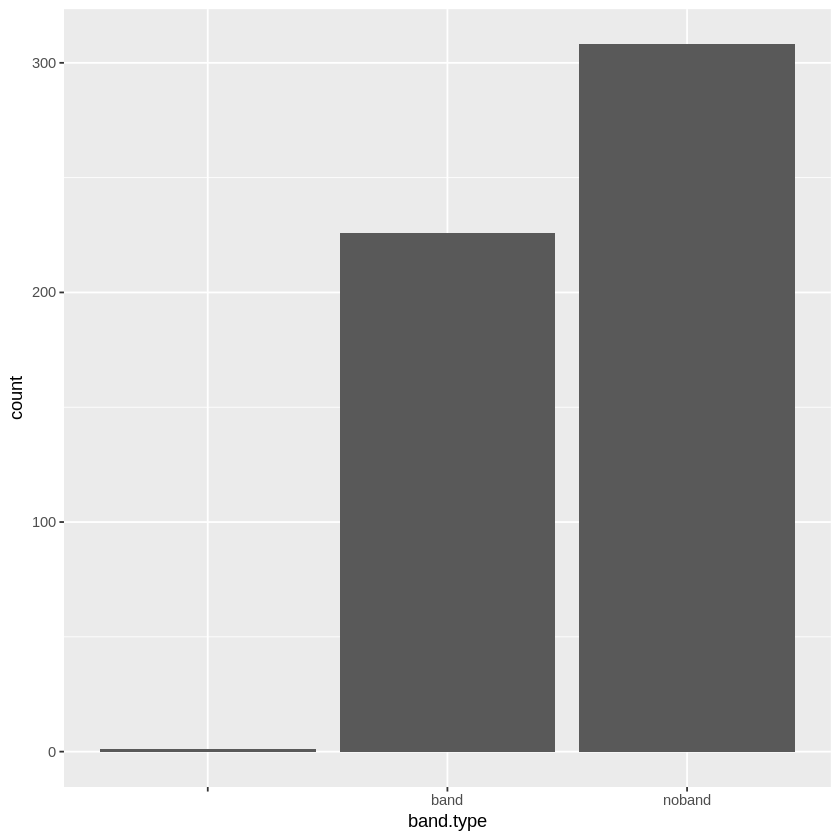

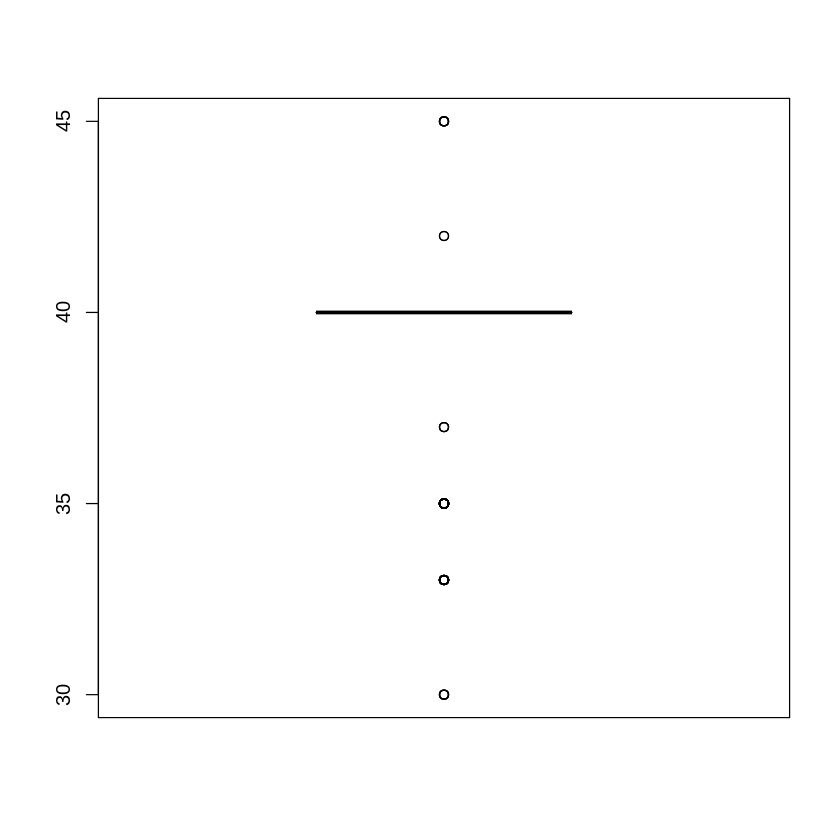

In [ ]:
library(ggplot2)

# Primero se grafica el histograma de var. categórica
ggplot(original.dataset, aes(x = band.type)) + geom_bar()
table(original.dataset$blade.pressure)

# Ahora se grafica el boxplot de var. numérica
boxplot (original.dataset$current.density)

## Ejercicio 3 (complemento): Análisis con herramientas de IA

Un complemento ideal en este tipo de casos es aprovechar herramientas de IA generativa, como ChatGPT, Gemini, Copilot y otros. Aquí se propone hacer un análisis general, de la siguiente forma:

1. Descargar el archivo CSV de la referencia (https://rsolver.com/download/CylinderBand.csv)
2. Subirlo a algún asistentes inteligente, de preferencia de la persona. Si trabajan en grupo se recomienda probar diferentes.
3. Realizar análisis utilizando prompts como el ejemplo siguiente
4. Verificar resultados y refinar prompt para ir complementando.


-----------------

**Prompt sugerido**

> Realiza un análisis exploratorio de datos (EDA) completo del dataset “Cylinder Bands” adjunto.  
Tu análisis debe incluir:

1. **Carga y descripción inicial**
   - Carga del dataset y verificación de estructura (filas, columnas, tipos de variables, valores faltantes).
   - Identificación de variables numéricas y categóricas.
   - Resumen estadístico general (media, mediana, desviación, mínimos y máximos).

2. **Calidad de datos**
   - Conteo y proporción de valores nulos por variable.
   - Revisión de valores atípicos y duplicados.
   - Revisión de consistencia en variables categóricas (número de categorías, valores erróneos o inconsistentes).

3. **Análisis univariado**
   - Distribución de cada variable numérica mediante histogramas o boxplots.
   - Distribución de las variables categóricas mediante gráficos de barras.

4. **Análisis bivariado**
   - Correlaciones entre variables numéricas (matriz de correlación y mapa de calor).
   - Comparaciones entre variables numéricas y la variable objetivo (“band_type” o equivalente).
   - Tablas cruzadas y visualizaciones entre variables categóricas relevantes y la clase objetivo.

5. **Insights iniciales**
   - Variables que parecen más influyentes sobre el resultado o calidad del cilindro.
   - Posibles relaciones no lineales o dependencias entre variables.
   - Problemas potenciales de desequilibrio de clases.

6. **Preparación para modelado**
   - Identificación de variables que requieran imputación o transformación.
   - Posibles codificaciones de variables categóricas y normalización de numéricas.
   - Observaciones sobre la viabilidad para un modelo de clasificación o regresión.

Entrega el análisis con visualizaciones, interpretaciones claras y conclusiones resumidas por sección.



#Parte 2: Mejoras al Dataset

## Ejercicio 4: Limpieza y refinamiento del dataset

Según el ejercicio 2 y 3, aparecieron columnas con valores vacíos ("NA"), por lo que se vuelve importante tomar una decisión de cómo tratar los registros que tienen datos vacíos.

Una alternativa, especialmente válida cuando la proporción de casos con vacíos es baja (por ej, menos de un 10%), es eliminar los registros que tengan esos casos.

**Preguntas Ejercicio 4**

4.1   Mirando el resultado de la instrucción siguiente, ¿Ud. optaría por corregir datos incompletos o derechamente eliminar aquellas filas (y en este caso, cuántas serían aprox)? ¿Por qué?

4.2   Si opta por eliminar aquellas filas con datos incompletos, ¿cuántas filas quedarían?

**Explicación de comandos e instrucciones en R relevantes y útiles para esto**

Es válido buscar referencias en Internet que ayuden a usar estos comandos y responder las preguntas planteadas, aunque es posible que se resuelvan con lo siguiente.

*   *colnames(dataset)* permite obtener la lista de columnas del dataset de nombre 'dataset'
*   *sapply(dataset, function(x) sum(*condicion*))* aplica la condición a cada una de las celdas del dataset, obteniendo la suma por cada columna
*   Para detectar atributos con valores "no disponibles" la condicion de una celda x es: *is.na(x)*
*   Para eliminar filas con atributos "vacíos", se puede usar el comando: *clean.dataset <- na.omit(original.dataset)*

In [ ]:
# A continuación agregar las instrucciones para resolver las preguntas indicadas
sapply(original.dataset, function(x) sum(is.na(x)))

clean.dataset <- original.dataset

# (A) ¿Cuáles columnas se pueden eliminar para mejorar la calidad de los datos? (Consider al menos 2)
# Se eliminan columnas con las siguientes instrucciones de ejemplo:
clean.dataset$plating.tank <- NULL

# A continuación se eliminan los registros que tienen algún NA (antes: 'unknown')
clean.dataset <- na.omit(clean.dataset)

# Se ve el tamaño del dataset. Mientras más grande (cantidad de filas) y limpio quede, mejor
dim(clean.dataset)
sapply(clean.dataset, function(x) sum(is.na(x)))

timestamp              Change     cylinder.number            customer 
                  0                   0                   0                   0 
         job.number      grain.screened           ink.color    proof.on.ctd.ink 
                  0                  49                   0                  57 
          blade.mfg   cylinder.division          paper.type            ink.type 
                 60                   0                   0                   0 
       direct.steam        solvent.type          press.type               press 
                 25                  55                   0                   0 
        unit.number       cylinder.size paper.mill.location        plating.tank 
                  0                   3                 155                  19 
          proof.cut           viscosity             caliper     ink.temperature 
                 55                   6                  27                   3 
           humifity           roughness      blade.pressure         varnish.pct 
                  2                  29                  62                  56 
        press.speed             ink.pct         solvent.pct         ESA.Voltage 
                  9                  56                  56                  57 
       ESA.Amperage                 wax            hardener    roller.durometer 
                 55                   7                   8                  55 
    current.density   anode.space.ratio      chrome.content           band.type 
                  8                   8                   4                   0

[1] 283  39

timestamp              Change     cylinder.number            customer 
                  0                   0                   0                   0 
         job.number      grain.screened           ink.color    proof.on.ctd.ink 
                  0                   0                   0                   0 
          blade.mfg   cylinder.division          paper.type            ink.type 
                  0                   0                   0                   0 
       direct.steam        solvent.type          press.type               press 
                  0                   0                   0                   0 
        unit.number       cylinder.size paper.mill.location           proof.cut 
                  0                   0                   0                   0 
          viscosity             caliper     ink.temperature            humifity 
                  0                   0                   0                   0 
          roughness      blade.pressure         varnish.pct         press.speed 
                  0                   0                   0                   0 
            ink.pct         solvent.pct         ESA.Voltage        ESA.Amperage 
                  0                   0                   0                   0 
                wax            hardener    roller.durometer     current.density 
                  0                   0                   0                   0 
  anode.space.ratio      chrome.content           band.type 
                  0                   0                   0